# Volatility Regime Modeling Pipeline

In [54]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

import pandas as pd

ROOT: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling


Configurations

In [55]:
RUN_INGESTION = False  # set True if you want to refetch/clean/merge in notebook

START_DATE = "2018-01-01"
ASSET_TICKERS = ["SPY", "QQQ", "AAPL"]
VIX_TICKERS = ["^VIX"]

RAW_DIR = ROOT / "data" / "raw"
CLEAN_DIR = ROOT / "data" / "clean"
INTERIM_DIR = ROOT / "data" / "interim"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports" / "baselines"

RAW_ASSETS_PATH = RAW_DIR / "ohlcv_SPY-QQQ-AAPL_2018-01-01_latest_1d.parquet"
RAW_VIX_PATH = RAW_DIR / "vix_VIX_2018-01-01_latest_1d.parquet"

CLEAN_ASSETS_PATH = CLEAN_DIR / "assets_clean.parquet"
CLEAN_VIX_PATH = CLEAN_DIR / "vix_clean.parquet"

MERGED_PATH = INTERIM_DIR / "ohlcv_with_vix.parquet"
FEATURES_PATH = PROCESSED_DIR / "vol_features_5d.parquet"

HORIZON_DAYS = 5
TRAIN_END = "2022-12-30"
VAL_START = "2023-01-03"
VAL_END = "2023-12-29"
TEST_START = "2024-01-02"
N_REGIMES = 3

Data Ingestion

In [56]:
from src.pipeline.ingest import FetchSpec, fetch_ohlcv, clean_ohlcv, merge_assets_with_vix

if RUN_INGESTION:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    CLEAN_DIR.mkdir(parents=True, exist_ok=True)
    INTERIM_DIR.mkdir(parents=True, exist_ok=True)

    # Fetch raw
    assets_raw = fetch_ohlcv(FetchSpec(tickers=ASSET_TICKERS, start=START_DATE))
    vix_raw = fetch_ohlcv(FetchSpec(tickers=VIX_TICKERS, start=START_DATE))

    assets_raw.to_parquet(RAW_ASSETS_PATH, index=False)
    vix_raw.to_parquet(RAW_VIX_PATH, index=False)

    # Clean
    assets_clean = clean_ohlcv(assets_raw)
    vix_clean = clean_ohlcv(vix_raw)

    assets_clean.to_parquet(CLEAN_ASSETS_PATH, index=False)
    vix_clean.to_parquet(CLEAN_VIX_PATH, index=False)

    # Merge
    merged = merge_assets_with_vix(assets_clean, vix_clean)
    merged.to_parquet(MERGED_PATH, index=False)

    print("Ingestion complete:", MERGED_PATH)

else:
    print("Skipping ingestion. Expecting merged file at:", MERGED_PATH)

Skipping ingestion. Expecting merged file at: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/interim/ohlcv_with_vix.parquet


Reading Data

In [57]:
df = pd.read_parquet(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Tickers:", sorted(df["ticker"].astype(str).unique()))
df.head()

Shape: (6123, 13)
Date range: 2018-01-02 → 2026-02-13
Tickers: ['AAPL', 'QQQ', 'SPY']


,date,ticker,open,high,low,close,adj_close,volume,vix_close,vix_volume,vix_log_return,vix_rv_10,vix_rv_20
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.304176,102223600,9.77,0,NaN,NaN,NaN
1,2018-01-03,AAPL,43.132500,43.637501,42.990002,43.057499,40.297157,118071600,9.15,0,-0.065563,NaN,NaN
2,2018-01-04,AAPL,43.134998,43.367500,43.020000,43.257500,40.484325,89738400,9.22,0,0.007621,NaN,NaN
3,2018-01-05,AAPL,43.360001,43.842499,43.262501,43.750000,40.945263,94640000,9.22,0,0.000000,NaN,NaN
4,2018-01-08,AAPL,43.587502,43.902500,43.482498,43.587502,40.793182,82271200,9.52,0,0.032020,NaN,NaN


Feature Engineering

In [58]:
from src.pipeline.features import build_features_and_labels

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

feat = build_features_and_labels(
    merged_df=df,
    horizon_days=HORIZON_DAYS,
    train_end=TRAIN_END,
    n_regimes=N_REGIMES,
)

feat.to_parquet(FEATURES_PATH, index=False)

print("Saved features:", FEATURES_PATH)
print("Shape:", feat.shape)
feat[["date", "ticker", "regime", f"fwd_rv_{HORIZON_DAYS}"]].head()

Saved features: /Users/tanzimc/Desktop/SIADS 696/SIADS696-volatility-regime-modeling/data/processed/vol_features_5d.parquet
Shape: (5928, 30)


,date,ticker,regime,fwd_rv_5
0,2018-03-29,AAPL,2,0.277560
1,2018-04-02,AAPL,2,0.274886
2,2018-04-03,AAPL,2,0.292819
3,2018-04-04,AAPL,2,0.272819
4,2018-04-05,AAPL,2,0.277536


## Cross Validation

In [90]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

TARGET = "regime"

# --- choose ticker + TRAIN-ONLY window for CV ---
cv_df = feat[(feat["ticker"] == "SPY") & (feat["date"] <= TRAIN_END)].copy()
cv_df = cv_df.sort_values("date").reset_index(drop=True)

# --- IMPORTANT: drop forward-looking columns (leakage) ---
fwd_cols = [c for c in cv_df.columns if c.startswith("fwd_") or c.startswith("fwd")]
# (this will catch fwd_rv_5 / fwd_rv_{HORIZON_DAYS})

drop_cols = {TARGET, "date", "ticker", *fwd_cols}

feature_cols = [
    c for c in cv_df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(cv_df[c])
]

print("Dropped forward cols:", fwd_cols)
print("#features:", len(feature_cols))

X = cv_df[feature_cols]
y = cv_df[TARGET].astype(int)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), feature_cols)
    ],
    remainder="drop",
)

models = {
    "logreg": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=4000, C=1.0, class_weight=None)),
    ]),
    "random_forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
            max_depth=None,
            min_samples_leaf=1,
            max_features="sqrt",
        )),
    ]),
    "grad_boost": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            random_state=42,
        )),
    ]),
}

# --- gap prevents forward-window overlap leakage ---
tscv = TimeSeriesSplit(n_splits=5, gap=HORIZON_DAYS)

rows = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    train_end = cv_df.loc[train_idx, "date"].max()
    val_start = cv_df.loc[val_idx, "date"].min()
    val_end = cv_df.loc[val_idx, "date"].max()

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rows.append({
            "fold": fold,
            "model": name,
            "val_macro_f1": f1_score(y_va, pred, average="macro"),
            "val_accuracy": accuracy_score(y_va, pred),
            "train_end": str(pd.to_datetime(train_end).date()),
            "val_start": str(pd.to_datetime(val_start).date()),
            "val_end": str(pd.to_datetime(val_end).date()),
            "n_train": len(train_idx),
            "n_val": len(val_idx),
        })

cv_results = pd.DataFrame(rows)
summary = (cv_results
           .groupby("model")[["val_macro_f1", "val_accuracy"]]
           .agg(["mean", "std"])
           .sort_values(("val_macro_f1", "mean"), ascending=False))

display(cv_results)
display(summary)

out_path = "data/processed/cv_timeseries_spy_5fold_gap.csv"
import os
os.makedirs("data/processed", exist_ok=True)
cv_results.to_csv(out_path, index=False)
print("Saved:", out_path)

Dropped forward cols: ['fwd_rv_5']
#features: 26


,fold,model,val_macro_f1,val_accuracy,train_end,val_start,val_end,n_train,n_val
0,1,logreg,0.342346,0.467337,2019-01-11,2019-01-22,2019-11-01,199,199
1,1,random_forest,0.472327,0.743719,2019-01-11,2019-01-22,2019-11-01,199,199
2,1,grad_boost,0.424910,0.718593,2019-01-11,2019-01-22,2019-11-01,199,199
3,2,logreg,0.464247,0.457286,2019-10-25,2019-11-04,2020-08-18,398,199
4,2,random_forest,0.316719,0.512563,2019-10-25,2019-11-04,2020-08-18,398,199
5,2,grad_boost,0.555333,0.633166,2019-10-25,2019-11-04,2020-08-18,398,199
6,3,logreg,0.249764,0.286432,2020-08-11,2020-08-19,2021-06-03,597,199
7,3,random_forest,0.393274,0.572864,2020-08-11,2020-08-19,2021-06-03,597,199
8,3,grad_boost,0.337355,0.437186,2020-08-11,2020-08-19,2021-06-03,597,199
9,4,logreg,0.438581,0.643216,2021-05-26,2021-06-04,2022-03-17,796,199


val_macro_f1           val_accuracy          
                      mean       std         mean       std
model                                                      
grad_boost        0.399209  0.102073     0.540704  0.166042
random_forest     0.366949  0.074931     0.539698  0.152817
logreg            0.350593  0.099325     0.441206  0.135744

Saved: data/processed/cv_timeseries_spy_5fold_gap.csv


In [59]:
display(feat["regime"].value_counts().sort_index())
display(feat.groupby("ticker")["regime"].value_counts().sort_index())

regime
0    2241
1    2137
2    1550
Name: count, dtype: int64

ticker  regime
AAPL    0          433
        1          743
        2          800
QQQ     0          691
        1          771
        2          514
SPY     0         1117
        1          623
        2          236
Name: count, dtype: int64

Regime Distribution Over Time

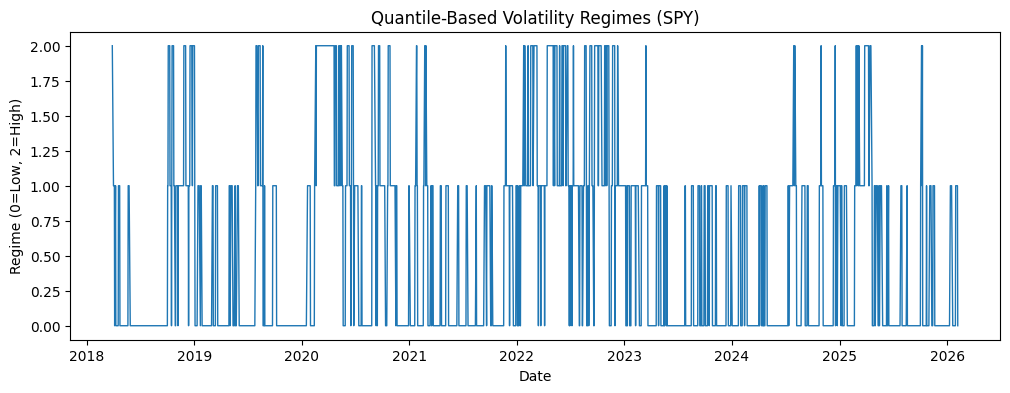

In [91]:
import matplotlib.pyplot as plt

spy = feat[feat["ticker"] == "SPY"].copy()
spy = spy.sort_values("date")

plt.figure(figsize=(12,4))
plt.plot(spy["date"], spy["regime"], linewidth=1)
plt.title("Quantile-Based Volatility Regimes (SPY)")
plt.ylabel("Regime (0=Low, 2=High)")
plt.xlabel("Date")
plt.show()

Forward Volatility Distribution

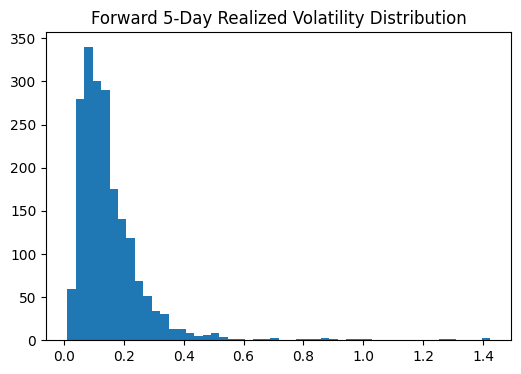

In [92]:
plt.figure(figsize=(6,4))
plt.hist(spy["fwd_rv_5"], bins=50)
plt.title("Forward 5-Day Realized Volatility Distribution")
plt.show()

Basline Model Training

In [93]:
from src.pipeline.train import SplitSpec, train_baselines_3way

split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)

res = train_baselines_3way(df=feat, target="regime", split=split)

print("=== Split ===")
print(res["split"])
print("\n#features:", len(res["features"]))

for model_name, m in res["models"].items():
    print(f"\n=== {model_name} ===")
    print("VAL  | acc:", round(m["val"]["accuracy"], 4), "macro_f1:", round(m["val"]["macro_f1"], 4))
    print("TEST | acc:", round(m["test"]["accuracy"], 4), "macro_f1:", round(m["test"]["macro_f1"], 4))
    print("VAL confusion:", m["val"]["confusion_matrix"])
    print("TEST confusion:", m["test"]["confusion_matrix"])

=== Split ===
{'train': {'start': '2018-03-29', 'end': '2022-12-30', 'n': 3597}, 'val': {'start': '2023-01-03', 'end': '2023-12-29', 'n': 750}, 'test': {'start': '2024-01-02', 'end': '2026-02-06', 'n': 1581}}

#features: 26

=== logreg ===
VAL  | acc: 0.5307 macro_f1: 0.4301
TEST | acc: 0.5142 macro_f1: 0.4659
VAL confusion: [[195, 112, 6], [133, 193, 44], [15, 42, 10]]
TEST confusion: [[457, 263, 9], [244, 292, 32], [57, 163, 64]]

=== random_forest ===
VAL  | acc: 0.52 macro_f1: 0.4305
TEST | acc: 0.5168 macro_f1: 0.459
VAL confusion: [[229, 76, 8], [184, 148, 38], [20, 34, 13]]
TEST confusion: [[471, 227, 31], [230, 284, 54], [70, 152, 62]]


## Hyperparameter tuning plan (targeted)

After establishing baseline performance, we tune a small set of hyperparameters that most directly control
model complexity and generalization:

- Logistic Regression: regularization strength (C) and class weighting
- Random Forest: tree depth and leaf size (controls overfitting), plus max_features (tree diversity)

We select hyperparameters using validation Macro F1 (primary metric) and keep the test set untouched
until final evaluation.

In [94]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# assumes you already have train_df, val_df from your 3-way split
TARGET = "regime"

drop_cols = {TARGET, "date", "ticker"}
# prevent leakage: never allow fwd_* columns as features
fwd_cols = [c for c in feat.columns if c.startswith("fwd_") or c.startswith("fwd")]
drop_cols |= set(fwd_cols)

feature_cols = [c for c in feat.columns
                if c not in drop_cols and pd.api.types.is_numeric_dtype(feat[c])]

preprocessor = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feature_cols)],
    remainder="drop",
)

X_tr, y_tr = train_df[feature_cols], train_df[TARGET].astype(int)
X_va, y_va = val_df[feature_cols], val_df[TARGET].astype(int)

def eval_model(model):
    pred = model.predict(X_va)
    return {
        "val_macro_f1": f1_score(y_va, pred, average="macro"),
        "val_acc": accuracy_score(y_va, pred),
    }

# -----------------------
# 1) Logistic Regression tuning
# -----------------------
lr_grid = []
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    for cw in [None, "balanced"]:
        lr = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=4000, C=C, class_weight=cw)),
        ])
        lr.fit(X_tr, y_tr)
        scores = eval_model(lr)
        lr_grid.append({"model":"logreg", "C":C, "class_weight":cw, **scores})

lr_res = pd.DataFrame(lr_grid).sort_values("val_macro_f1", ascending=False)
display(lr_res.head(10))

best_lr = lr_res.iloc[0].to_dict()
print("Best LR:", best_lr)

# -----------------------
# 2) Random Forest tuning (targeted)
# -----------------------
rf_grid = []
for max_depth in [4, 8, 12, None]:
    for min_leaf in [1, 5, 10]:
        for max_feat in ["sqrt", 0.5]:
            rf = Pipeline([
                ("prep", preprocessor),
                ("clf", RandomForestClassifier(
                    n_estimators=400,
                    random_state=42,
                    n_jobs=-1,
                    class_weight="balanced_subsample",
                    max_depth=max_depth,
                    min_samples_leaf=min_leaf,
                    max_features=max_feat,
                )),
            ])
            rf.fit(X_tr, y_tr)
            scores = eval_model(rf)
            rf_grid.append({
                "model":"random_forest",
                "max_depth":max_depth,
                "min_samples_leaf":min_leaf,
                "max_features":max_feat,
                **scores
            })

rf_res = pd.DataFrame(rf_grid).sort_values("val_macro_f1", ascending=False)
display(rf_res.head(10))

best_rf = rf_res.iloc[0].to_dict()
print("Best RF:", best_rf)

,model,C,class_weight,val_macro_f1,val_acc
4,logreg,1.00,NaN,0.430116,0.530667
5,logreg,1.00,balanced,0.430116,0.530667
6,logreg,10.00,NaN,0.422262,0.510667
7,logreg,10.00,balanced,0.422262,0.510667
8,logreg,100.00,NaN,0.419489,0.510667
9,logreg,100.00,balanced,0.419489,0.510667
2,logreg,0.10,NaN,0.395522,0.514667
3,logreg,0.10,balanced,0.395522,0.514667
0,logreg,0.01,NaN,0.380126,0.506667
1,logreg,0.01,balanced,0.380126,0.506667


Best LR: {'model': 'logreg', 'C': 1.0, 'class_weight': nan, 'val_macro_f1': 0.4301155879726688, 'val_acc': 0.5306666666666666}


,model,max_depth,min_samples_leaf,max_features,val_macro_f1,val_acc
18,random_forest,NaN,1,sqrt,0.430543,0.520000
19,random_forest,NaN,1,0.5,0.417540,0.526667
4,random_forest,4.0,10,sqrt,0.395231,0.506667
22,random_forest,NaN,10,sqrt,0.393223,0.524000
16,random_forest,12.0,10,sqrt,0.391311,0.521333
20,random_forest,NaN,5,sqrt,0.390881,0.521333
8,random_forest,8.0,5,sqrt,0.389098,0.526667
6,random_forest,8.0,1,sqrt,0.388857,0.526667
21,random_forest,NaN,5,0.5,0.388258,0.514667
10,random_forest,8.0,10,sqrt,0.387939,0.524000


Best RF: {'model': 'random_forest', 'max_depth': nan, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'val_macro_f1': 0.4305426015779323, 'val_acc': 0.52}


## Final supervised evaluation (LogReg + HistGradientBoosting)

We evaluate the final supervised models on the fixed chronological split:
Train (2018–2022), Validation (2023), Test (2024–2026).  
Hyperparameters are selected using VAL Macro F1 only; TEST is held out for final reporting.

In [140]:
import os, json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from src.pipeline.train import SplitSpec, time_split_3way

# -----------------------------
# Split
# -----------------------------
split = SplitSpec(
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
)
train_df, val_df, test_df = time_split_3way(feat, split)

TARGET = "regime"

# -----------------------------
# Features (IMPORTANT: exclude forward columns)
# -----------------------------
fwd_cols = [c for c in feat.columns if c.startswith("fwd_") or c.startswith("fwd")]
drop_cols = {TARGET, "date", "ticker", *fwd_cols}

feature_cols = [
    c for c in feat.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(feat[c])
]

print("Dropped forward cols:", fwd_cols)
print("#features:", len(feature_cols))

# -----------------------------
# Preprocess (fit inside pipeline; no leakage)
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feature_cols)],
    remainder="drop",
)

# -----------------------------
# Models (baseline configs)
# -----------------------------
models = {
    "logreg": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=4000, C=1.0, class_weight=None)),
    ]),
    "hgboost": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            random_state=42,
        )),
    ]),
}

def eval_model(model, df, split_name):
    X = df[feature_cols]
    y = df[TARGET].astype(int).values
    pred = model.predict(X)
    return {
        f"{split_name}_acc": float(accuracy_score(y, pred)),
        f"{split_name}_macro_f1": float(f1_score(y, pred, average="macro")),
        f"{split_name}_confusion": confusion_matrix(y, pred).tolist(),
        "pred": pred,
    }

# Fit on TRAIN only, evaluate on VAL + TEST
results = {}
pred_frames = []

for name, model in models.items():
    model.fit(train_df[feature_cols], train_df[TARGET].astype(int))
    
    val_out = eval_model(model, val_df, "val")
    test_out = eval_model(model, test_df, "test")

    results[name] = {
        "val_acc": val_out["val_acc"],
        "val_macro_f1": val_out["val_macro_f1"],
        "test_acc": test_out["test_acc"],
        "test_macro_f1": test_out["test_macro_f1"],
        "val_confusion": val_out["val_confusion"],
        "test_confusion": test_out["test_confusion"],
    }

    # save predictions for later visuals/failure analysis
    for split_name, df, pred in [("val", val_df, val_out["pred"]), ("test", test_df, test_out["pred"])]:
        tmp = df[["date", "ticker", TARGET]].copy()
        tmp["split"] = split_name
        tmp["model"] = name
        tmp["pred"] = pred
        pred_frames.append(tmp)

print(json.dumps(results, indent=2))

os.makedirs("data/processed", exist_ok=True)
with open("data/processed/final_supervised_metrics_logreg_hgboost.json", "w") as f:
    json.dump(results, f, indent=2)

preds = pd.concat(pred_frames).reset_index(drop=True)
preds.to_parquet("data/processed/final_supervised_preds_logreg_hgboost.parquet", index=False)

print("Saved metrics: data/processed/final_supervised_metrics_logreg_hgboost.json")
print("Saved preds:   data/processed/final_supervised_preds_logreg_hgboost.parquet")


# --- Save LogReg-only metrics (for final comparison loader) ---
logreg_summary = {
    "val_acc": results["logreg"]["val_acc"],
    "val_macro_f1": results["logreg"]["val_macro_f1"],
    "test_acc": results["logreg"]["test_acc"],
    "test_macro_f1": results["logreg"]["test_macro_f1"],
    "val_confusion": results["logreg"]["val_confusion"],
    "test_confusion": results["logreg"]["test_confusion"],
}

with open("data/processed/final_logreg_metrics.json", "w") as f:
    json.dump(logreg_summary, f, indent=2)

print("Saved: data/processed/final_logreg_metrics.json")

Dropped forward cols: ['fwd_rv_5']
#features: 26
{
  "logreg": {
    "val_acc": 0.5306666666666666,
    "val_macro_f1": 0.4301155879726688,
    "test_acc": 0.5142314990512334,
    "test_macro_f1": 0.46594351320369864,
    "val_confusion": [
      [
        195,
        112,
        6
      ],
      [
        133,
        193,
        44
      ],
      [
        15,
        42,
        10
      ]
    ],
    "test_confusion": [
      [
        457,
        263,
        9
      ],
      [
        244,
        292,
        32
      ],
      [
        57,
        163,
        64
      ]
    ]
  },
  "hgboost": {
    "val_acc": 0.5106666666666667,
    "val_macro_f1": 0.419389500340048,
    "test_acc": 0.519291587602783,
    "test_macro_f1": 0.44891274591101205,
    "val_confusion": [
      [
        223,
        74,
        16
      ],
      [
        166,
        147,
        57
      ],
      [
        19,
        35,
        13
      ]
    ],
    "test_confusion": [
      [
        531,
 

Targeted HGB Tuning

In [96]:
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score

X_tr = train_df[feature_cols]
y_tr = train_df[TARGET].astype(int)
X_va = val_df[feature_cols]
y_va = val_df[TARGET].astype(int)

grid = []
for max_depth in [2, 3, None]:
    for min_samples_leaf in [20, 50, 100]:
        for lr in [0.03, 0.05, 0.1]:
            for max_iter in [200, 400]:
                model = Pipeline([
                    ("prep", preprocessor),
                    ("clf", HistGradientBoostingClassifier(
                        random_state=42,
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        learning_rate=lr,
                        max_iter=max_iter,
                    )),
                ])
                model.fit(X_tr, y_tr)
                pred = model.predict(X_va)
                grid.append({
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "learning_rate": lr,
                    "max_iter": max_iter,
                    "val_macro_f1": f1_score(y_va, pred, average="macro"),
                    "val_acc": accuracy_score(y_va, pred),
                })

hgb_res = pd.DataFrame(grid).sort_values("val_macro_f1", ascending=False)
display(hgb_res.head(15))

best_hgb = hgb_res.iloc[0].to_dict()
print("Best HGB:", best_hgb)

hgb_res.to_csv("data/processed/hgb_tuning_grid_val.csv", index=False)
print("Saved: data/processed/hgb_tuning_grid_val.csv")

,max_depth,min_samples_leaf,learning_rate,max_iter,val_macro_f1,val_acc
34,3.0,100,0.10,200,0.432109,0.518667
27,3.0,50,0.05,400,0.431797,0.532000
46,NaN,50,0.10,200,0.427250,0.496000
44,NaN,50,0.05,200,0.426453,0.514667
23,3.0,20,0.10,400,0.426409,0.533333
33,3.0,100,0.05,400,0.425270,0.521333
39,NaN,20,0.05,400,0.423975,0.509333
51,NaN,100,0.05,400,0.423654,0.508000
53,NaN,100,0.10,400,0.421901,0.513333
48,NaN,100,0.03,200,0.421022,0.516000


Best HGB: {'max_depth': 3.0, 'min_samples_leaf': 100.0, 'learning_rate': 0.1, 'max_iter': 200.0, 'val_macro_f1': 0.43210921916721484, 'val_acc': 0.5186666666666667}
Saved: data/processed/hgb_tuning_grid_val.csv


Evaluation using Tuned HG Boost vs LogReg

In [98]:
best = best_hgb  # dict from your tuning results

# --- cast params safely ---
max_depth = None if pd.isna(best["max_depth"]) or best["max_depth"] is None else int(best["max_depth"])
min_samples_leaf = int(best["min_samples_leaf"])
learning_rate = float(best["learning_rate"])
max_iter = int(best["max_iter"])

tuned_hgboost = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        learning_rate=learning_rate,
        max_iter=max_iter,
    )),
])

tuned_hgboost.fit(train_df[feature_cols], train_df[TARGET].astype(int))

# Evaluate on VAL + TEST
def quick_eval(model, df, name):
    y = df[TARGET].astype(int).values
    pred = model.predict(df[feature_cols])
    return {
        f"{name}_acc": float(accuracy_score(y, pred)),
        f"{name}_macro_f1": float(f1_score(y, pred, average="macro")),
        f"{name}_confusion": confusion_matrix(y, pred).tolist(),
    }

tuned_results = {
    "hgboost_tuned": {
        **quick_eval(tuned_hgboost, val_df, "val"),
        **quick_eval(tuned_hgboost, test_df, "test"),
        "best_params": best,
    }
}

print(json.dumps(tuned_results, indent=2))

with open("data/processed/final_hgboost_tuned_metrics.json", "w") as f:
    json.dump(tuned_results, f, indent=2)

print("Saved: data/processed/final_hgboost_tuned_metrics.json")

{
  "hgboost_tuned": {
    "val_acc": 0.5186666666666667,
    "val_macro_f1": 0.43210921916721484,
    "val_confusion": [
      [
        213,
        90,
        10
      ],
      [
        170,
        163,
        37
      ],
      [
        15,
        39,
        13
      ]
    ],
    "test_acc": 0.5230866540164453,
    "test_macro_f1": 0.45073721826865193,
    "test_confusion": [
      [
        537,
        170,
        22
      ],
      [
        289,
        233,
        46
      ],
      [
        89,
        138,
        57
      ]
    ],
    "best_params": {
      "max_depth": 3.0,
      "min_samples_leaf": 100.0,
      "learning_rate": 0.1,
      "max_iter": 200.0,
      "val_macro_f1": 0.43210921916721484,
      "val_acc": 0.5186666666666667
    }
  }
}
Saved: data/processed/final_hgboost_tuned_metrics.json


Final Supervised Artifact

In [99]:
import os, json
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# assumes: preprocessor, feature_cols, train_df/val_df/test_df, best_hgb already exist
TARGET = "regime"

# --- tuned HGB params from best_hgb ---
max_depth = None if pd.isna(best_hgb["max_depth"]) or best_hgb["max_depth"] is None else int(best_hgb["max_depth"])
min_samples_leaf = int(best_hgb["min_samples_leaf"])
learning_rate = float(best_hgb["learning_rate"])
max_iter = int(best_hgb["max_iter"])

models = {
    "logreg_final": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=4000, C=1.0, class_weight=None)),
    ]),
    "hgboost_tuned": Pipeline([
        ("prep", preprocessor),
        ("clf", HistGradientBoostingClassifier(
            random_state=42,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            learning_rate=learning_rate,
            max_iter=max_iter,
        )),
    ]),
}

def eval_and_collect(model, df, split_name):
    X = df[feature_cols]
    y = df[TARGET].astype(int).values
    pred = model.predict(X)
    return {
        f"{split_name}_acc": float(accuracy_score(y, pred)),
        f"{split_name}_macro_f1": float(f1_score(y, pred, average="macro")),
        f"{split_name}_confusion": confusion_matrix(y, pred).tolist(),
        "pred": pred,
    }

metrics = {}
pred_rows = []

for name, model in models.items():
    model.fit(train_df[feature_cols], train_df[TARGET].astype(int))

    val_out = eval_and_collect(model, val_df, "val")
    test_out = eval_and_collect(model, test_df, "test")

    metrics[name] = {
        "val_acc": val_out["val_acc"],
        "val_macro_f1": val_out["val_macro_f1"],
        "test_acc": test_out["test_acc"],
        "test_macro_f1": test_out["test_macro_f1"],
        "val_confusion": val_out["val_confusion"],
        "test_confusion": test_out["test_confusion"],
    }
    if name == "hgboost_tuned":
        metrics[name]["best_params"] = {
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "learning_rate": learning_rate,
            "max_iter": max_iter,
        }

    for split_name, df, pred in [("val", val_df, val_out["pred"]), ("test", test_df, test_out["pred"])]:
        tmp = df[["date", "ticker", TARGET]].copy()
        tmp["split"] = split_name
        tmp["model"] = name
        tmp["pred"] = pred
        pred_rows.append(tmp)

os.makedirs("data/processed", exist_ok=True)

with open("data/processed/final_supervised_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

preds = pd.concat(pred_rows).reset_index(drop=True)
preds.to_parquet("data/processed/final_supervised_preds.parquet", index=False)

print("Saved: data/processed/final_supervised_metrics.json")
print("Saved: data/processed/final_supervised_preds.parquet")
print(json.dumps(metrics, indent=2))

Saved: data/processed/final_supervised_metrics.json
Saved: data/processed/final_supervised_preds.parquet
{
  "logreg_final": {
    "val_acc": 0.5306666666666666,
    "val_macro_f1": 0.4301155879726688,
    "test_acc": 0.5142314990512334,
    "test_macro_f1": 0.46594351320369864,
    "val_confusion": [
      [
        195,
        112,
        6
      ],
      [
        133,
        193,
        44
      ],
      [
        15,
        42,
        10
      ]
    ],
    "test_confusion": [
      [
        457,
        263,
        9
      ],
      [
        244,
        292,
        32
      ],
      [
        57,
        163,
        64
      ]
    ]
  },
  "hgboost_tuned": {
    "val_acc": 0.5186666666666667,
    "val_macro_f1": 0.43210921916721484,
    "test_acc": 0.5230866540164453,
    "test_macro_f1": 0.45073721826865193,
    "val_confusion": [
      [
        213,
        90,
        10
      ],
      [
        170,
        163,
        37
      ],
      [
        15,
        39,
 

Confusion Matrices

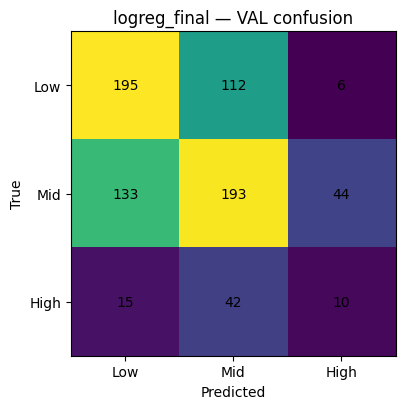

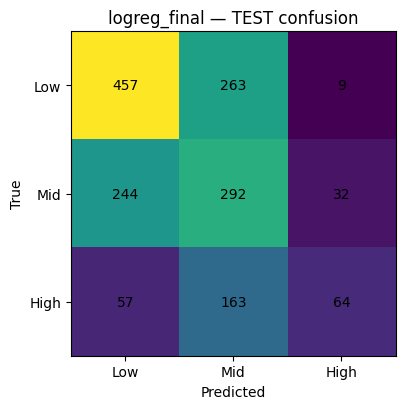

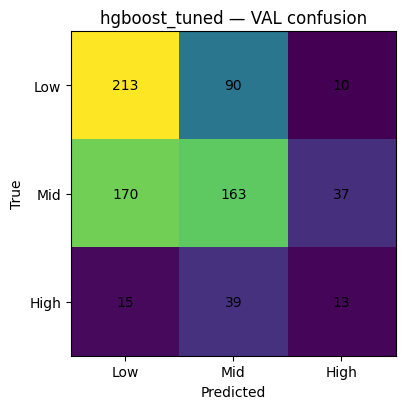

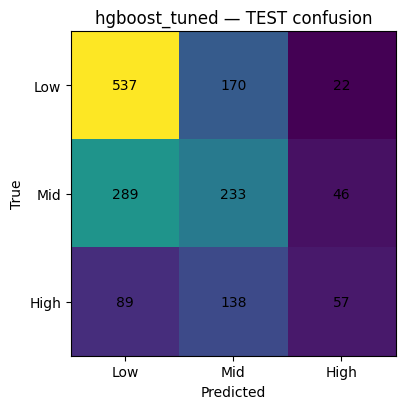

In [100]:
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS_PATH = "data/processed/final_supervised_metrics.json"  # adjust if needed

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

CLASS_NAMES = ["Low", "Mid", "High"]  # regimes 0,1,2

def plot_cm(cm, title, class_names=CLASS_NAMES):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # annotate counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

# Plot all models in the JSON
for model_name, m in metrics.items():
    plot_cm(m["val_confusion"],  f"{model_name} — VAL confusion")
    plot_cm(m["test_confusion"], f"{model_name} — TEST confusion")

In [101]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS_PATH = "data/processed/final_supervised_metrics.json"
OUT_DIR = "reports/figures"
os.makedirs(OUT_DIR, exist_ok=True)

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

CLASS_NAMES = ["Low", "Mid", "High"]

def save_cm(cm, title, out_path, class_names=CLASS_NAMES):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

for model_name, m in metrics.items():
    save_cm(m["val_confusion"],  f"{model_name} — VAL confusion",
            os.path.join(OUT_DIR, f"cm_{model_name}_val.png"))
    save_cm(m["test_confusion"], f"{model_name} — TEST confusion",
            os.path.join(OUT_DIR, f"cm_{model_name}_test.png"))

print("Saved confusion matrices to:", OUT_DIR)

Saved confusion matrices to: reports/figures


Model Comparison Visualization

In [103]:
import json
import pandas as pd

METRICS_PATH = "data/processed/final_supervised_metrics.json"  # adjust if needed

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

rows = []
for model_name, m in metrics.items():
    rows.append({
        "model": model_name,
        "val_macro_f1": m.get("val_macro_f1"),
        "test_macro_f1": m.get("test_macro_f1"),
        "val_acc": m.get("val_acc"),
        "test_acc": m.get("test_acc"),
    })

df_comp = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
display(df_comp)

,model,val_macro_f1,test_macro_f1,val_acc,test_acc
1,hgboost_tuned,0.432109,0.450737,0.518667,0.523087
0,logreg_final,0.430116,0.465944,0.530667,0.514231


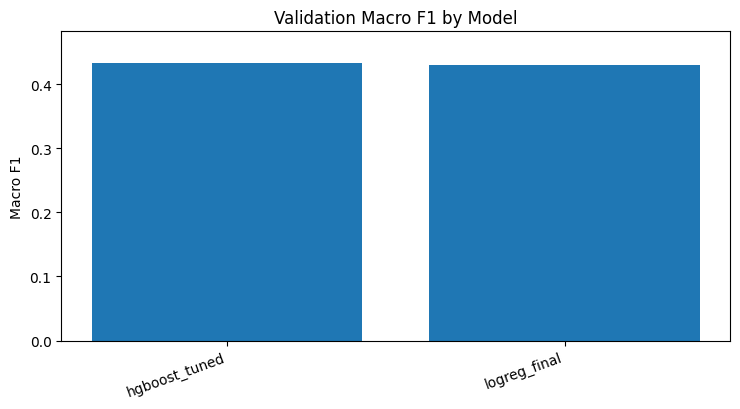

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# expects df_comp from previous cell
models = df_comp["model"].tolist()
vals = df_comp["val_macro_f1"].astype(float).values

x = np.arange(len(models))

plt.figure(figsize=(7.5, 4.2))
plt.bar(x, vals)
plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1 by Model")
plt.ylim(0, max(vals) + 0.05)
plt.tight_layout()
plt.show()

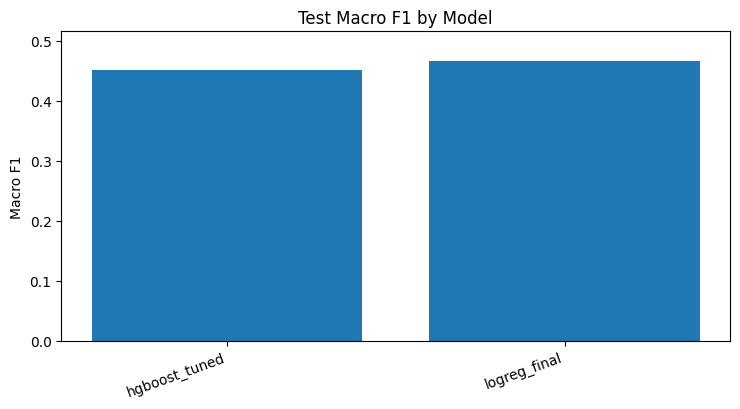

In [105]:
import numpy as np
import matplotlib.pyplot as plt

models = df_comp["model"].tolist()
vals = df_comp["test_macro_f1"].astype(float).values

x = np.arange(len(models))

plt.figure(figsize=(7.5, 4.2))
plt.bar(x, vals)
plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Macro F1")
plt.title("Test Macro F1 by Model")
plt.ylim(0, max(vals) + 0.05)
plt.tight_layout()
plt.show()

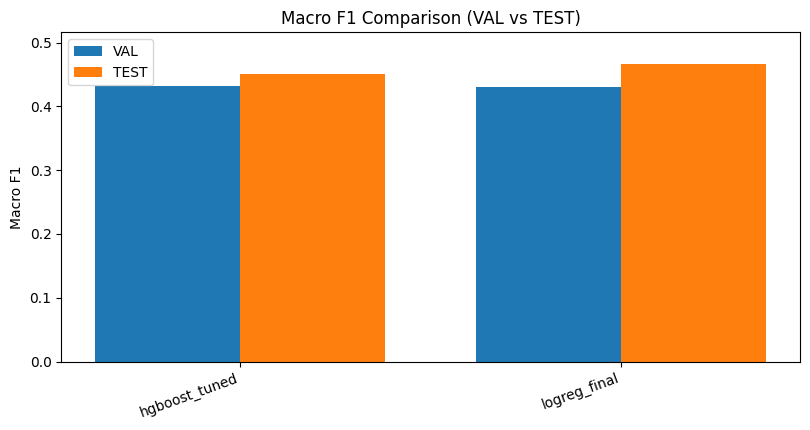

In [106]:
import numpy as np
import matplotlib.pyplot as plt

models = df_comp["model"].tolist()
val_f1 = df_comp["val_macro_f1"].astype(float).values
test_f1 = df_comp["test_macro_f1"].astype(float).values

x = np.arange(len(models))
w = 0.38

plt.figure(figsize=(8.2, 4.4))
plt.bar(x - w/2, val_f1, width=w, label="VAL")
plt.bar(x + w/2, test_f1, width=w, label="TEST")
plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison (VAL vs TEST)")
plt.ylim(0, max(val_f1.max(), test_f1.max()) + 0.05)
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "reports/figures"
os.makedirs(OUT_DIR, exist_ok=True)

models = df_comp["model"].tolist()
val_f1 = df_comp["val_macro_f1"].astype(float).values
test_f1 = df_comp["test_macro_f1"].astype(float).values

x = np.arange(len(models))
w = 0.38

plt.figure(figsize=(8.2, 4.4))
plt.bar(x - w/2, val_f1, width=w, label="VAL")
plt.bar(x + w/2, test_f1, width=w, label="TEST")
plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison (VAL vs TEST)")
plt.ylim(0, max(val_f1.max(), test_f1.max()) + 0.05)
plt.legend()
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "model_comparison_macro_f1_val_test.png")
plt.savefig(out_path, dpi=200)
plt.close()

print("Saved:", out_path)

Saved: reports/figures/model_comparison_macro_f1_val_test.png


## Baseline vs Tuned Comparison Visual

,model,baseline_val,tuned_val,baseline_test,tuned_test
0,logreg,0.430116,0.430116,0.465944,0.465944
1,hgboost,0.419390,0.432109,0.448913,0.450737


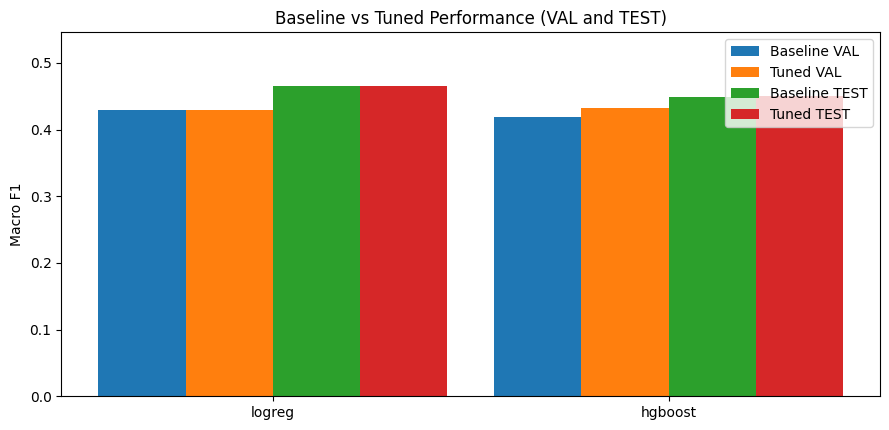

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- fill from your existing outputs ----
# baseline metrics
baseline = {
    "logreg": {"val_macro_f1": results["logreg"]["val_macro_f1"], "test_macro_f1": results["logreg"]["test_macro_f1"]},
    "hgboost": {"val_macro_f1": results["hgboost"]["val_macro_f1"], "test_macro_f1": results["hgboost"]["test_macro_f1"]},
}

# tuned metrics (HGB tuned; LR tuned is identical to baseline in your case)
tuned = {
    "logreg": {"val_macro_f1": results["logreg"]["val_macro_f1"], "test_macro_f1": results["logreg"]["test_macro_f1"]},
    "hgboost": {"val_macro_f1": tuned_results["hgboost_tuned"]["val_macro_f1"], "test_macro_f1": tuned_results["hgboost_tuned"]["test_macro_f1"]},
}

df = pd.DataFrame({
    "model": ["logreg", "hgboost"],
    "baseline_val": [baseline["logreg"]["val_macro_f1"], baseline["hgboost"]["val_macro_f1"]],
    "tuned_val":    [tuned["logreg"]["val_macro_f1"],    tuned["hgboost"]["val_macro_f1"]],
    "baseline_test":[baseline["logreg"]["test_macro_f1"], baseline["hgboost"]["test_macro_f1"]],
    "tuned_test":   [tuned["logreg"]["test_macro_f1"],   tuned["hgboost"]["test_macro_f1"]],
})

display(df)

x = np.arange(len(df["model"]))
w = 0.22

plt.figure(figsize=(9, 4.4))
plt.bar(x - 1.5*w, df["baseline_val"], width=w, label="Baseline VAL")
plt.bar(x - 0.5*w, df["tuned_val"], width=w, label="Tuned VAL")
plt.bar(x + 0.5*w, df["baseline_test"], width=w, label="Baseline TEST")
plt.bar(x + 1.5*w, df["tuned_test"], width=w, label="Tuned TEST")

plt.xticks(x, df["model"], rotation=0)
plt.ylabel("Macro F1")
plt.title("Baseline vs Tuned Performance (VAL and TEST)")
plt.ylim(0, max(df[["baseline_val","tuned_val","baseline_test","tuned_test"]].max()) + 0.08)
plt.legend()
plt.tight_layout()
plt.show()

## Feature Ablation

In [109]:
import numpy as np
import pandas as pd

from copy import deepcopy
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

TARGET = "regime"

# -----------------------------
# 0) Define feature groups
# -----------------------------
all_feats = list(feature_cols)

asset_drop_prefixes = ("vix_",)  # asset-only = drop vix features
vix_keep_prefix = "vix_"         # vix-only = keep only vix features

def asset_only_features(cols):
    return [c for c in cols if not c.startswith(asset_drop_prefixes)]

def vix_only_features(cols):
    return [c for c in cols if c.startswith(vix_keep_prefix)]

feat_sets = {
    "FULL": all_feats,
    "ASSET_ONLY": asset_only_features(all_feats),
    "VIX_ONLY": vix_only_features(all_feats),
}

for k, cols in feat_sets.items():
    print(f"{k}: {len(cols)} features")

# -----------------------------
# 1) Build models (final)
# -----------------------------
# tuned HGB params from best_hgb
max_depth = None if pd.isna(best_hgb["max_depth"]) or best_hgb["max_depth"] is None else int(best_hgb["max_depth"])
min_samples_leaf = int(best_hgb["min_samples_leaf"])
learning_rate = float(best_hgb["learning_rate"])
max_iter = int(best_hgb["max_iter"])

def make_preprocessor(cols):
    return ColumnTransformer(
        transformers=[("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), cols)],
        remainder="drop",
    )

def make_models(cols):
    prep = make_preprocessor(cols)
    return {
        "logreg": Pipeline([
            ("prep", prep),
            ("clf", LogisticRegression(max_iter=4000, C=1.0, class_weight=None)),
        ]),
        "hgboost_tuned": Pipeline([
            ("prep", prep),
            ("clf", HistGradientBoostingClassifier(
                random_state=42,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                learning_rate=learning_rate,
                max_iter=max_iter,
            )),
        ]),
    }

def score(model, df, cols, split_name):
    X = df[cols]
    y = df[TARGET].astype(int).values
    pred = model.predict(X)
    return {
        f"{split_name}_macro_f1": float(f1_score(y, pred, average="macro")),
        f"{split_name}_acc": float(accuracy_score(y, pred)),
    }

# -----------------------------
# 2) Run ablation
# -----------------------------
rows = []
for set_name, cols in feat_sets.items():
    models = make_models(cols)

    for mname, model in models.items():
        model.fit(train_df[cols], train_df[TARGET].astype(int))

        val_scores = score(model, val_df, cols, "val")
        test_scores = score(model, test_df, cols, "test")

        rows.append({
            "feature_set": set_name,
            "model": mname,
            **val_scores,
            **test_scores,
            "n_features": len(cols),
        })

ablation_results = pd.DataFrame(rows).sort_values(["model", "feature_set"])
display(ablation_results)

FULL: 26 features
ASSET_ONLY: 18 features
VIX_ONLY: 8 features


,feature_set,model,val_macro_f1,val_acc,test_macro_f1,test_acc,n_features
3,ASSET_ONLY,hgboost_tuned,0.403387,0.485333,0.460998,0.488299,18
1,FULL,hgboost_tuned,0.432109,0.518667,0.450737,0.523087,26
5,VIX_ONLY,hgboost_tuned,0.392390,0.513333,0.419758,0.495256,8
2,ASSET_ONLY,logreg,0.384621,0.512000,0.390551,0.404175,18
0,FULL,logreg,0.430116,0.530667,0.465944,0.514231,26
4,VIX_ONLY,logreg,0.335934,0.488000,0.437937,0.527514,8


### Feature Ablation Impact Visuals

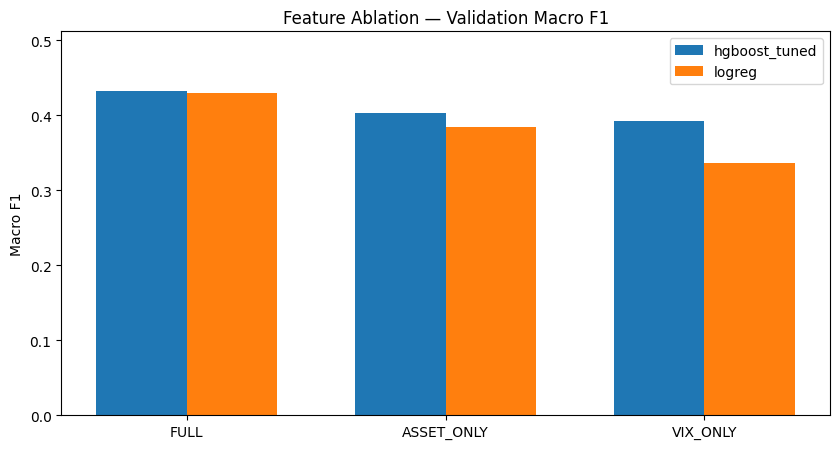

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# expects: ablation_results dataframe
dfv = ablation_results.copy()

# Order the feature sets nicely
feat_order = ["FULL", "ASSET_ONLY", "VIX_ONLY"]
dfv["feature_set"] = pd.Categorical(dfv["feature_set"], categories=feat_order, ordered=True)
dfv = dfv.sort_values(["model", "feature_set"])

models = sorted(dfv["model"].unique())
x = np.arange(len(feat_order))
w = 0.35 if len(models) == 2 else 0.25

plt.figure(figsize=(8.5, 4.6))

for i, m in enumerate(models):
    sub = dfv[dfv["model"] == m].set_index("feature_set").loc[feat_order]
    offset = (i - (len(models)-1)/2) * w
    plt.bar(x + offset, sub["val_macro_f1"].values, width=w, label=m)

plt.xticks(x, feat_order)
plt.ylabel("Macro F1")
plt.title("Feature Ablation — Validation Macro F1")
plt.ylim(0, dfv["val_macro_f1"].max() + 0.08)
plt.legend()
plt.tight_layout()
plt.show()

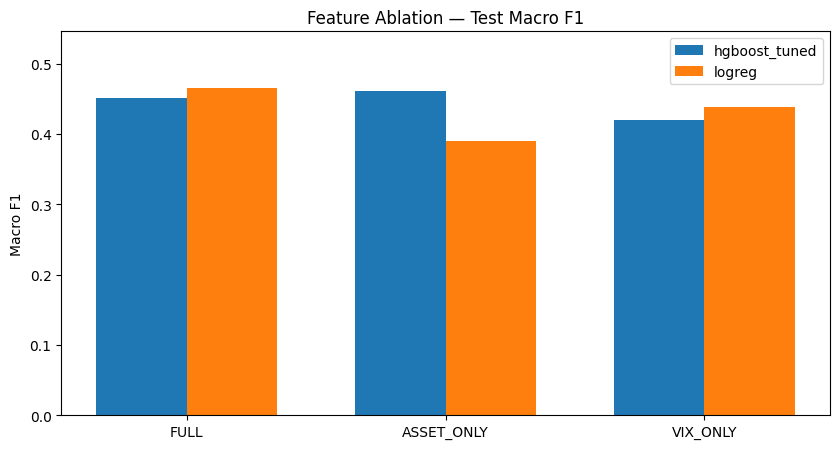

In [111]:
import numpy as np
import matplotlib.pyplot as plt

dft = ablation_results.copy()

feat_order = ["FULL", "ASSET_ONLY", "VIX_ONLY"]
dft["feature_set"] = pd.Categorical(dft["feature_set"], categories=feat_order, ordered=True)
dft = dft.sort_values(["model", "feature_set"])

models = sorted(dft["model"].unique())
x = np.arange(len(feat_order))
w = 0.35 if len(models) == 2 else 0.25

plt.figure(figsize=(8.5, 4.6))

for i, m in enumerate(models):
    sub = dft[dft["model"] == m].set_index("feature_set").loc[feat_order]
    offset = (i - (len(models)-1)/2) * w
    plt.bar(x + offset, sub["test_macro_f1"].values, width=w, label=m)

plt.xticks(x, feat_order)
plt.ylabel("Macro F1")
plt.title("Feature Ablation — Test Macro F1")
plt.ylim(0, dft["test_macro_f1"].max() + 0.08)
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("reports/figures", exist_ok=True)

def plot_and_save(metric_col, title, out_name):
    df = ablation_results.copy()
    feat_order = ["FULL", "ASSET_ONLY", "VIX_ONLY"]
    df["feature_set"] = pd.Categorical(df["feature_set"], categories=feat_order, ordered=True)
    df = df.sort_values(["model", "feature_set"])
    models = sorted(df["model"].unique())
    x = np.arange(len(feat_order))
    w = 0.35 if len(models) == 2 else 0.25

    plt.figure(figsize=(8.5, 4.6))
    for i, m in enumerate(models):
        sub = df[df["model"] == m].set_index("feature_set").loc[feat_order]
        offset = (i - (len(models)-1)/2) * w
        plt.bar(x + offset, sub[metric_col].values, width=w, label=m)

    plt.xticks(x, feat_order)
    plt.ylabel("Macro F1")
    plt.title(title)
    plt.ylim(0, df[metric_col].max() + 0.08)
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join("reports/figures", out_name)
    plt.savefig(out_path, dpi=200)
    plt.close()
    print("Saved:", out_path)

plot_and_save("val_macro_f1", "Feature Ablation — Validation Macro F1", "ablation_val_macro_f1.png")
plot_and_save("test_macro_f1", "Feature Ablation — Test Macro F1", "ablation_test_macro_f1.png")

Saved: reports/figures/ablation_val_macro_f1.png
Saved: reports/figures/ablation_test_macro_f1.png


## Failure Analysis

In [146]:
import pandas as pd
import numpy as np

PRED_PATH = "data/processed/final_supervised_preds_logreg_hgboost.parquet"
preds = pd.read_parquet(PRED_PATH).copy()

preds["true"] = preds["regime"].astype(int)
preds["pred"] = preds["pred"].astype(int)
preds["is_error"] = preds["true"] != preds["pred"]
preds["abs_err"] = (preds["pred"] - preds["true"]).abs()

display(preds.head())
print("Rows:", len(preds), "| Errors:", preds["is_error"].sum())

,date,ticker,regime,split,model,pred,true,is_error,abs_err
0,2023-01-03,AAPL,2,val,logreg,2,2,False,0
1,2023-01-04,AAPL,2,val,logreg,2,2,False,0
2,2023-01-05,AAPL,1,val,logreg,2,1,True,1
3,2023-01-06,AAPL,0,val,logreg,2,0,True,2
4,2023-01-09,AAPL,0,val,logreg,1,0,True,1


Rows: 4662 | Errors: 2247


In [147]:
# Error rate by model/split
err_summary = (preds
    .groupby(["model", "split"])
    .agg(
        n=("is_error", "size"),
        error_rate=("is_error", "mean"),
        mean_abs_err=("abs_err", "mean")
    )
    .reset_index()
)
display(err_summary)

# Which confusions are most common? (TEST only)
test = preds[preds["split"] == "test"]
conf_counts = (test[test["is_error"]]
    .groupby(["model", "true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values(["model", "count"], ascending=[True, False])
)
display(conf_counts.head(20))

,model,split,n,error_rate,mean_abs_err
0,hgboost,test,1581,0.480708,0.554712
1,hgboost,val,750,0.489333,0.536000
2,logreg,test,1581,0.485769,0.527514
3,logreg,val,750,0.469333,0.497333


,model,true,pred,count
2,hgboost,1,0,285
0,hgboost,0,1,169
5,hgboost,2,1,137
4,hgboost,2,0,88
3,hgboost,1,2,52
1,hgboost,0,2,29
6,logreg,0,1,263
8,logreg,1,0,244
11,logreg,2,1,163
10,logreg,2,0,57


In [148]:
def pick_failures(df, model_name, split_name="test", k=3):
    sub = df[(df["model"] == model_name) & (df["split"] == split_name) & (df["is_error"])].copy()
    sub = sub.sort_values(["abs_err", "date"], ascending=[False, True])

    picks = []

    # 1) Try to include a "far" mistake (abs_err=2) if present
    far = sub[sub["abs_err"] == 2]
    if len(far) > 0:
        picks.append(far.iloc[0])

    # 2) Add most frequent confusion types
    # build confusion frequency table
    freq = (sub.groupby(["true", "pred"]).size().reset_index(name="count")
              .sort_values("count", ascending=False))
    for _, row in freq.iterrows():
        if len(picks) >= k:
            break
        t, p = int(row["true"]), int(row["pred"])
        candidate = sub[(sub["true"] == t) & (sub["pred"] == p)]
        if len(candidate) == 0:
            continue
        # pick earliest instance of that confusion not already picked
        cand = candidate.iloc[0]
        if not any((x["date"] == cand["date"]) for x in picks):
            picks.append(cand)

    # fallback: just take top-k by abs_err/date
    if len(picks) < k:
        for _, r in sub.head(k - len(picks)).iterrows():
            picks.append(r)

    out = pd.DataFrame(picks).drop_duplicates(subset=["date", "model", "split"])
    return out[["date", "ticker", "model", "split", "true", "pred", "abs_err"]]

fail_logreg = pick_failures(preds, "logreg", "test", k=3)
fail_hgb = pick_failures(preds, "hgboost", "test", k=3)

display(fail_logreg)
display(fail_hgb)

,date,ticker,model,split,true,pred,abs_err
756,2024-01-10,AAPL,logreg,test,2,0,2
755,2024-01-09,AAPL,logreg,test,0,1,1
1277,2024-01-02,QQQ,logreg,test,1,0,1


,date,ticker,model,split,true,pred,abs_err
3087,2024-01-10,AAPL,hgboost,test,2,0,2
3081,2024-01-02,AAPL,hgboost,test,1,0,1
3103,2024-02-02,AAPL,hgboost,test,0,1,1


In [149]:
# choose a few columns to inspect around failures
CTX_COLS = ["date", "ticker", "regime", "log_return", "rv_10", "rv_20", "vix_close",
            "log_return_lag1", "log_return_lag2", "vix_log_return_lag1"]

def show_context(fail_row, window=5):
    d = pd.to_datetime(fail_row["date"])
    t = fail_row["ticker"]
    df = feat[feat["ticker"] == t].sort_values("date").reset_index(drop=True)

    # locate index
    idx = df.index[df["date"] == d]
    if len(idx) == 0:
        return None
    i = int(idx[0])
    lo = max(0, i - window)
    hi = min(len(df), i + window + 1)

    out = df.loc[lo:hi-1, [c for c in CTX_COLS if c in df.columns]].copy()
    out["is_failure_date"] = out["date"] == d
    return out

# Example: show context for first logreg failure
if len(fail_logreg) > 0:
    ctx = show_context(fail_logreg.iloc[0], window=7)
    display(ctx)

# Example: show context for first hgb failure
if len(fail_hgb) > 0:
    ctx = show_context(fail_hgb.iloc[0], window=7)
    display(ctx)

,date,ticker,regime,log_return,rv_10,rv_20,vix_close,log_return_lag1,log_return_lag2,vix_log_return_lag1,is_failure_date
1448,2023-12-29,AAPL,2,-0.005439,0.078090,0.143659,12.45,0.002224,0.000518,0.003213,False
1449,2024-01-02,AAPL,1,-0.036443,0.185739,0.192820,13.20,-0.005439,0.002224,-0.001605,False
1450,2024-01-03,AAPL,1,-0.007516,0.185453,0.191847,14.04,-0.036443,-0.005439,0.058496,False
1451,2024-01-04,AAPL,1,-0.012781,0.176148,0.176700,14.13,-0.007516,-0.036443,0.061694,False
1452,2024-01-05,AAPL,1,-0.004021,0.176368,0.176468,13.35,-0.012781,-0.007516,0.006390,False
1453,2024-01-08,AAPL,0,0.023887,0.235358,0.195767,13.08,-0.004021,-0.012781,-0.056784,False
1454,2024-01-09,AAPL,0,-0.002266,0.235639,0.192408,12.76,0.023887,-0.004021,-0.020432,False
1455,2024-01-10,AAPL,2,0.005655,0.241080,0.190638,12.69,-0.002266,0.023887,-0.024769,True
1456,2024-01-11,AAPL,2,-0.003228,0.240011,0.187164,12.44,0.005655,-0.002266,-0.005501,False
1457,2024-01-12,AAPL,2,0.001777,0.239697,0.174220,12.70,-0.003228,0.005655,-0.019897,False


,date,ticker,regime,log_return,rv_10,rv_20,vix_close,log_return_lag1,log_return_lag2,vix_log_return_lag1,is_failure_date
1448,2023-12-29,AAPL,2,-0.005439,0.078090,0.143659,12.45,0.002224,0.000518,0.003213,False
1449,2024-01-02,AAPL,1,-0.036443,0.185739,0.192820,13.20,-0.005439,0.002224,-0.001605,False
1450,2024-01-03,AAPL,1,-0.007516,0.185453,0.191847,14.04,-0.036443,-0.005439,0.058496,False
1451,2024-01-04,AAPL,1,-0.012781,0.176148,0.176700,14.13,-0.007516,-0.036443,0.061694,False
1452,2024-01-05,AAPL,1,-0.004021,0.176368,0.176468,13.35,-0.012781,-0.007516,0.006390,False
1453,2024-01-08,AAPL,0,0.023887,0.235358,0.195767,13.08,-0.004021,-0.012781,-0.056784,False
1454,2024-01-09,AAPL,0,-0.002266,0.235639,0.192408,12.76,0.023887,-0.004021,-0.020432,False
1455,2024-01-10,AAPL,2,0.005655,0.241080,0.190638,12.69,-0.002266,0.023887,-0.024769,True
1456,2024-01-11,AAPL,2,-0.003228,0.240011,0.187164,12.44,0.005655,-0.002266,-0.005501,False
1457,2024-01-12,AAPL,2,0.001777,0.239697,0.174220,12.70,-0.003228,0.005655,-0.019897,False


## Unsupervised Model 1 - Static Clustering (K-Means) - SPY Ticker

Fit K-Means

In [126]:
from sklearn.cluster import KMeans

# Use same OBS_COLS and standardized X
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

# Fit on TRAIN only (same as HMM)
kmeans.fit(X_train)

# Predict full sequence
kmeans_states = kmeans.predict(X_all)

hmm_df["kmeans_state"] = kmeans_states

print("Cluster counts:")
print(hmm_df["kmeans_state"].value_counts())

Cluster counts:
kmeans_state
0    1468
2     481
1      27
Name: count, dtype: int64


ARI/NMI For K-Means

In [127]:
print("VAL ARI/NMI (KMeans):", eval_ari_nmi(hmm_df, val_mask, state_col="kmeans_state"))
print("TEST ARI/NMI (KMeans):", eval_ari_nmi(hmm_df, test_mask, state_col="kmeans_state"))

VAL ARI/NMI (KMeans): {'ARI': 0.053597218051135515, 'NMI': 0.05302972710839999, 'n': 250}
TEST ARI/NMI (KMeans): {'ARI': 0.15843241239938327, 'NMI': 0.09700350885084165, 'n': 527}


Best Mapping (Train Only)

In [128]:
def best_mapping_kmeans(df, train_mask):
    y_train = df.loc[train_mask, "regime"].astype(int).values
    s_train = df.loc[train_mask, "kmeans_state"].astype(int).values
    
    best = None
    for perm in itertools.permutations(REGIMES, 3):
        mapping = {state: perm[state] for state in range(3)}
        pred = np.array([mapping[s] for s in s_train])
        mf1 = f1_score(y_train, pred, average="macro")
        if best is None or mf1 > best["macro_f1"]:
            best = {"mapping": mapping, "macro_f1": mf1}
    return best

best_km = best_mapping_kmeans(hmm_df, train_mask)
print("Best KMeans mapping:", best_km)

Best KMeans mapping: {'mapping': {0: np.int64(0), 1: np.int64(2), 2: np.int64(1)}, 'macro_f1': 0.4999630506479822}


Val/Test Macro F1

In [129]:
def eval_kmeans_mapped(df, mask, mapping):
    y = df.loc[mask, "regime"].astype(int).values
    s = df.loc[mask, "kmeans_state"].astype(int).values
    pred = np.array([mapping[x] for x in s])
    return {
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "acc": float(accuracy_score(y, pred))
    }

val_km = eval_kmeans_mapped(hmm_df, val_mask, best_km["mapping"])
test_km = eval_kmeans_mapped(hmm_df, test_mask, best_km["mapping"])

print("VAL KMeans:", val_km)
print("TEST KMeans:", test_km)

VAL KMeans: {'macro_f1': 0.31771815325114816, 'acc': 0.652}
TEST KMeans: {'macro_f1': 0.3926986048656751, 'acc': 0.6888045540796964}


Save K-Means Artifacts

In [135]:
kmeans_summary = {
    "ticker": TICKER_FOR_HMM,
    "val": val_km,
    "test": test_km,
}

with open("data/processed/kmeans_summary.json", "w") as f:
    json.dump(kmeans_summary, f, indent=2)

print("Saved: data/processed/kmeans_summary.json")

Saved: data/processed/kmeans_summary.json


K-Means Timeline

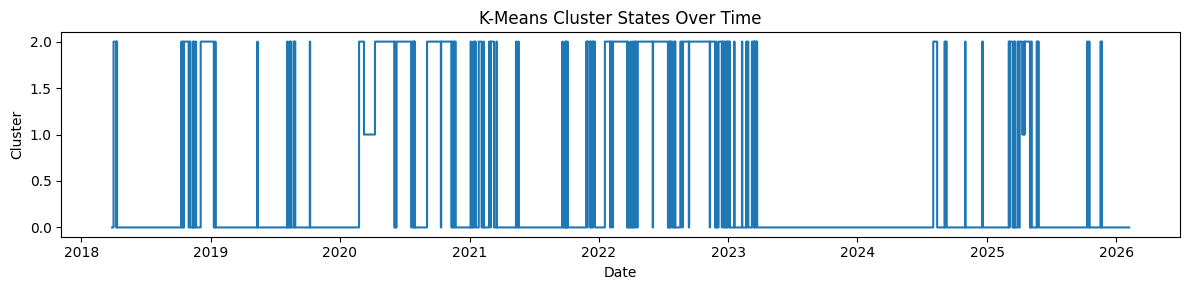

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(hmm_df["date"], hmm_df["kmeans_state"], drawstyle="steps-post")
plt.title("K-Means Cluster States Over Time")
plt.xlabel("Date")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

K-Means State vs Regime Heatmap

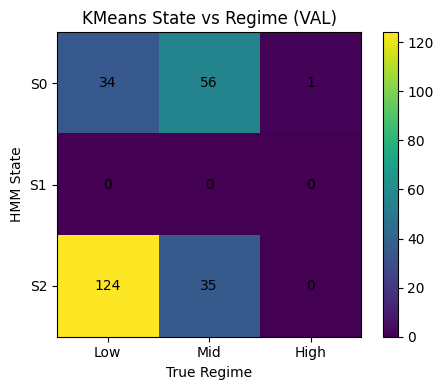

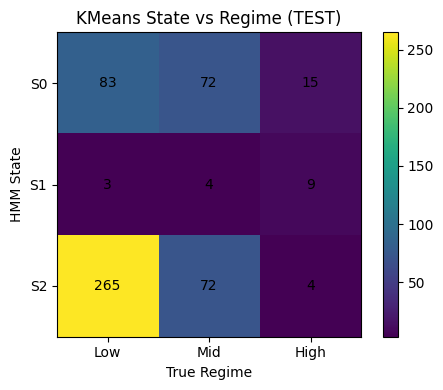

In [131]:
plot_state_vs_regime(hmm_df, val_mask, "KMeans State vs Regime (VAL)")
plot_state_vs_regime(hmm_df, test_mask, "KMeans State vs Regime (TEST)")

## Unsupervised Model 2 - Regime discovery with a Hidden Markov Model (HMM)

We now model volatility regimes as *latent states* rather than quantile-based labels.
An HMM assumes the market transitions between a small number of hidden regimes over time, and each regime generates
observable market behavior (returns, realized volatility, and VIX dynamics).

Steps:
1. Build an observation matrix from SPY features (returns, rolling volatility, VIX).
2. Fit a 3-state Gaussian HMM on the training period.
3. Decode the most likely hidden state sequence over train/val/test.
4. Compare hidden states to our supervised quantile regimes (alignment + transition behavior).

In [113]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# Pick which ticker to model with HMM
TICKER_FOR_HMM = "SPY"

# Observation columns: keep small + interpretable
OBS_COLS = ["log_return", "rv_10", "vix_close"]  # you can swap rv_20 etc if you want

hmm_df = feat[feat["ticker"] == TICKER_FOR_HMM].copy()
hmm_df = hmm_df.sort_values("date").reset_index(drop=True)

# Ensure required cols exist
missing = [c for c in OBS_COLS if c not in hmm_df.columns]
print("Missing observation cols:", missing)

# Drop rows with NA in obs cols (HMM needs dense sequence)
hmm_df = hmm_df.dropna(subset=OBS_COLS).reset_index(drop=True)

print("HMM rows:", len(hmm_df))
print("Date range:", hmm_df["date"].min().date(), "→", hmm_df["date"].max().date())

# Time splits (same as supervised)
train_end_dt = pd.to_datetime(TRAIN_END)
val_start_dt = pd.to_datetime(VAL_START)
val_end_dt   = pd.to_datetime(VAL_END)
test_start_dt = pd.to_datetime(TEST_START)

train_mask = hmm_df["date"] <= train_end_dt
val_mask = (hmm_df["date"] >= val_start_dt) & (hmm_df["date"] <= val_end_dt)
test_mask = hmm_df["date"] >= test_start_dt

print("Train/Val/Test sizes:", train_mask.sum(), val_mask.sum(), test_mask.sum())

X = hmm_df[OBS_COLS].values

# Standardize using TRAIN only (leakage-safe)
scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_mask])
X_all = scaler.transform(X)

Missing observation cols: []
HMM rows: 1976
Date range: 2018-03-29 → 2026-02-06
Train/Val/Test sizes: 1199 250 527


Fit HMM

In [115]:
from hmmlearn.hmm import GaussianHMM

N_STATES = 3

hmm_model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=500,
    random_state=42,
)

# Fit ONLY on training sequence
hmm_model.fit(X_train)

print("Converged:", hmm_model.monitor_.converged)
print("Iterations:", hmm_model.monitor_.iter)

Converged: True
Iterations: 44


Decode Hidden States

In [116]:
# Decode full sequence (using scaled X_all)
hmm_states = hmm_model.predict(X_all)

hmm_df["hmm_state"] = hmm_states

print(hmm_df["hmm_state"].value_counts())

hmm_state
2    950
0    832
1    194
Name: count, dtype: int64


Transition Matrix Heatmap

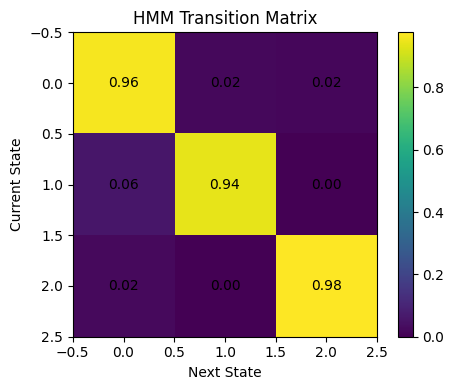

In [117]:
import matplotlib.pyplot as plt
import numpy as np

trans_mat = hmm_model.transmat_

plt.figure(figsize=(5, 4))
plt.imshow(trans_mat)
plt.title("HMM Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

for i in range(N_STATES):
    for j in range(N_STATES):
        plt.text(j, i, f"{trans_mat[i, j]:.2f}", ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

Print State Means

In [118]:
state_means = pd.DataFrame(
    hmm_model.means_,
    columns=OBS_COLS
)

display(state_means)

,log_return,rv_10,vix_close
0,-0.007193,0.046148,0.094726
1,-0.066907,1.478919,1.599365
2,0.037055,-0.676645,-0.788322


HMM State Timeline

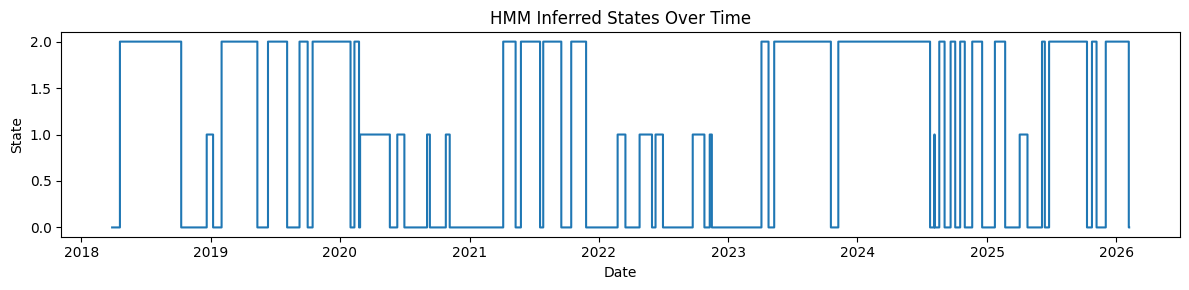

In [119]:
plt.figure(figsize=(12, 3))

plt.plot(hmm_df["date"], hmm_df["hmm_state"], drawstyle="steps-post")

plt.title("HMM Inferred States Over Time")
plt.xlabel("Date")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Evaluate Unsupervised Alignment

In [120]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def eval_ari_nmi(df, mask, label_col="regime", state_col="hmm_state"):
    y = df.loc[mask, label_col].astype(int).values
    s = df.loc[mask, state_col].astype(int).values
    return {
        "ARI": float(adjusted_rand_score(y, s)),
        "NMI": float(normalized_mutual_info_score(y, s)),
        "n": int(mask.sum())
    }

print("VAL ARI/NMI:", eval_ari_nmi(hmm_df, val_mask))
print("TEST ARI/NMI:", eval_ari_nmi(hmm_df, test_mask))

VAL ARI/NMI: {'ARI': 0.19273484780265834, 'NMI': 0.12584933139323584, 'n': 250}
TEST ARI/NMI: {'ARI': 0.16360339950509267, 'NMI': 0.1054610141833477, 'n': 527}


Best State Mapping -> Regime Mapping on Train Only

In [121]:
import itertools
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

N_STATES = hmm_df["hmm_state"].nunique()
REGIMES = sorted(hmm_df["regime"].dropna().astype(int).unique())

assert N_STATES == len(REGIMES), f"Need same #states and #regimes. Got {N_STATES} states vs {len(REGIMES)} regimes."

def best_mapping_by_train_macro_f1(df, train_mask):
    y_train = df.loc[train_mask, "regime"].astype(int).values
    s_train = df.loc[train_mask, "hmm_state"].astype(int).values

    best = None
    for perm in itertools.permutations(REGIMES, N_STATES):
        mapping = {state: perm[state] for state in range(N_STATES)}
        pred = np.array([mapping[s] for s in s_train])
        mf1 = f1_score(y_train, pred, average="macro")
        acc = accuracy_score(y_train, pred)
        if (best is None) or (mf1 > best["macro_f1"]):
            best = {"mapping": mapping, "macro_f1": mf1, "acc": acc}
    return best

best = best_mapping_by_train_macro_f1(hmm_df, train_mask)
best_mapping = best["mapping"]
print("Best mapping (state -> regime):", best_mapping)
print("TRAIN macro F1:", round(best["macro_f1"], 4), "| TRAIN acc:", round(best["acc"], 4))

Best mapping (state -> regime): {0: np.int64(1), 1: np.int64(2), 2: np.int64(0)}
TRAIN macro F1: 0.6044 | TRAIN acc: 0.6205


Apply Mapping and Compute Macro F1 on val and test

In [122]:
def eval_mapped(df, mask, mapping):
    y = df.loc[mask, "regime"].astype(int).values
    s = df.loc[mask, "hmm_state"].astype(int).values
    pred = np.array([mapping[x] for x in s])
    return {
        "macro_f1": float(f1_score(y, pred, average="macro")),
        "acc": float(accuracy_score(y, pred)),
        "confusion": confusion_matrix(y, pred, labels=[0,1,2]).tolist()
    }

val_mapped = eval_mapped(hmm_df, val_mask, best_mapping)
test_mapped = eval_mapped(hmm_df, test_mask, best_mapping)

print("VAL mapped:", {k: round(v, 4) if isinstance(v, float) else v for k, v in val_mapped.items() if k != "confusion"})
print("TEST mapped:", {k: round(v, 4) if isinstance(v, float) else v for k, v in test_mapped.items() if k != "confusion"})

VAL mapped: {'macro_f1': 0.4659, 'acc': 0.72}
TEST mapped: {'macro_f1': 0.5426, 'acc': 0.6565}


State vs Regime Heatmap (TRAIN, VAL, TEST)

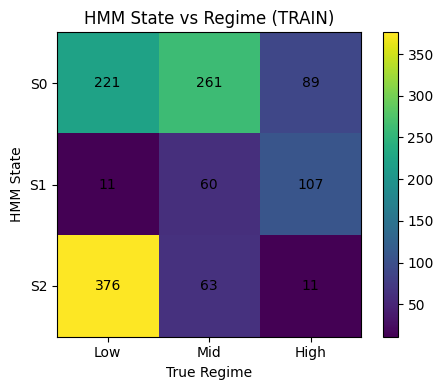

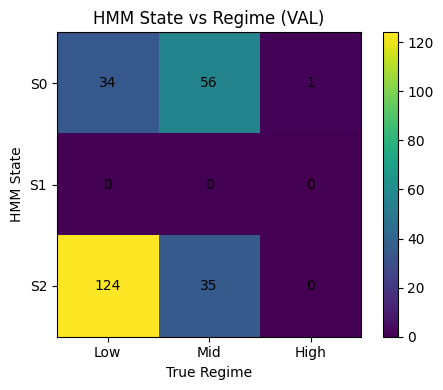

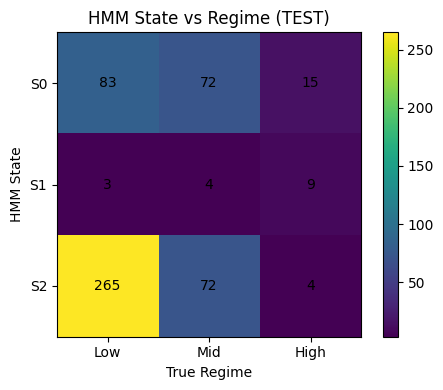

In [123]:
import matplotlib.pyplot as plt
import numpy as np

def plot_state_vs_regime(df, mask, title):
    sub = df.loc[mask, ["hmm_state", "regime"]].dropna().copy()
    sub["hmm_state"] = sub["hmm_state"].astype(int)
    sub["regime"] = sub["regime"].astype(int)

    mat = pd.crosstab(sub["hmm_state"], sub["regime"]).reindex(index=range(3), columns=range(3), fill_value=0)
    mat = mat.values

    plt.figure(figsize=(5, 4))
    plt.imshow(mat)
    plt.title(title)
    plt.xlabel("True Regime")
    plt.ylabel("HMM State")
    plt.xticks([0,1,2], ["Low","Mid","High"])
    plt.yticks([0,1,2], ["S0","S1","S2"])

    for i in range(3):
        for j in range(3):
            plt.text(j, i, str(mat[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_state_vs_regime(hmm_df, train_mask, "HMM State vs Regime (TRAIN)")
plot_state_vs_regime(hmm_df, val_mask,   "HMM State vs Regime (VAL)")
plot_state_vs_regime(hmm_df, test_mask,  "HMM State vs Regime (TEST)")

Save HMM Artifacts

In [125]:
import os, json
import numpy as np

os.makedirs("data/processed", exist_ok=True)

def to_jsonable(x):
    """Recursively convert numpy/pandas scalars/arrays to Python types."""
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.ndarray,)):
        return x.tolist()
    if isinstance(x, dict):
        return {str(k): to_jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [to_jsonable(v) for v in x]
    return x

# Save per-day states
cols_to_save = ["date", "ticker", "regime", "hmm_state"] + OBS_COLS
hmm_df[cols_to_save].to_parquet("data/processed/hmm_states_spy.parquet", index=False)

# Build summary (then convert to JSON-safe)
summary = {
    "ticker": TICKER_FOR_HMM,
    "obs_cols": OBS_COLS,
    "mapping": best_mapping,          # state -> regime
    "val": val_mapped,
    "test": test_mapped,
    "transmat": hmm_model.transmat_,  # numpy array
    "means": hmm_model.means_,        # numpy array
}

summary = to_jsonable(summary)

with open("data/processed/hmm_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: data/processed/hmm_states_spy.parquet")
print("Saved: data/processed/hmm_summary.json")

Saved: data/processed/hmm_states_spy.parquet
Saved: data/processed/hmm_summary.json


# Final Comparison Chart

In [144]:
import json
import os

def load_json(path):
    if not os.path.exists(path):
        print("Missing:", path)
        return None
    with open(path, "r") as f:
        return json.load(f)

hgboost_metrics = load_json("data/processed/final_hgboost_tuned_metrics.json")
logreg_metrics = load_json("data/processed/final_logreg_metrics.json")
hmm_summary = load_json("data/processed/hmm_summary.json")
kmeans_summary = load_json("data/processed/kmeans_summary.json")

comparison = {}

comparison["LogReg"] = logreg_metrics["test_macro_f1"]
comparison["HGB"] = hgboost_metrics["hgboost_tuned"]["test_macro_f1"]
comparison["KMeans"] = kmeans_summary["test"]["macro_f1"]
comparison["HMM"] = hmm_summary["test"]["macro_f1"]

print(comparison)

{'LogReg': 0.46594351320369864, 'HGB': 0.45073721826865193, 'KMeans': 0.3926986048656751, 'HMM': 0.54260568384246}


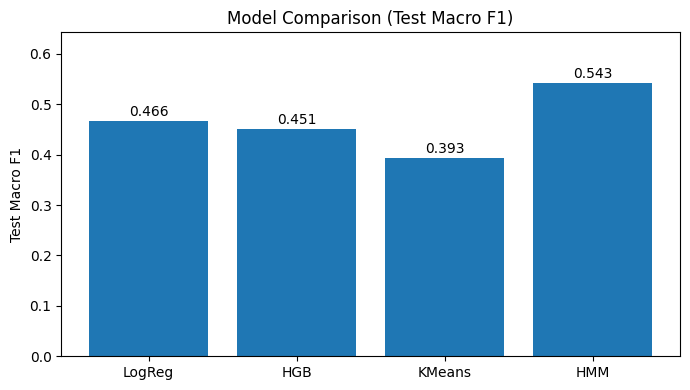

In [145]:
import matplotlib.pyplot as plt

models = list(comparison.keys())
scores = list(comparison.values())

plt.figure(figsize=(7,4))
plt.bar(models, scores)
plt.ylabel("Test Macro F1")
plt.title("Model Comparison (Test Macro F1)")
plt.ylim(0, max(scores) + 0.1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

## Final Regime Timeline

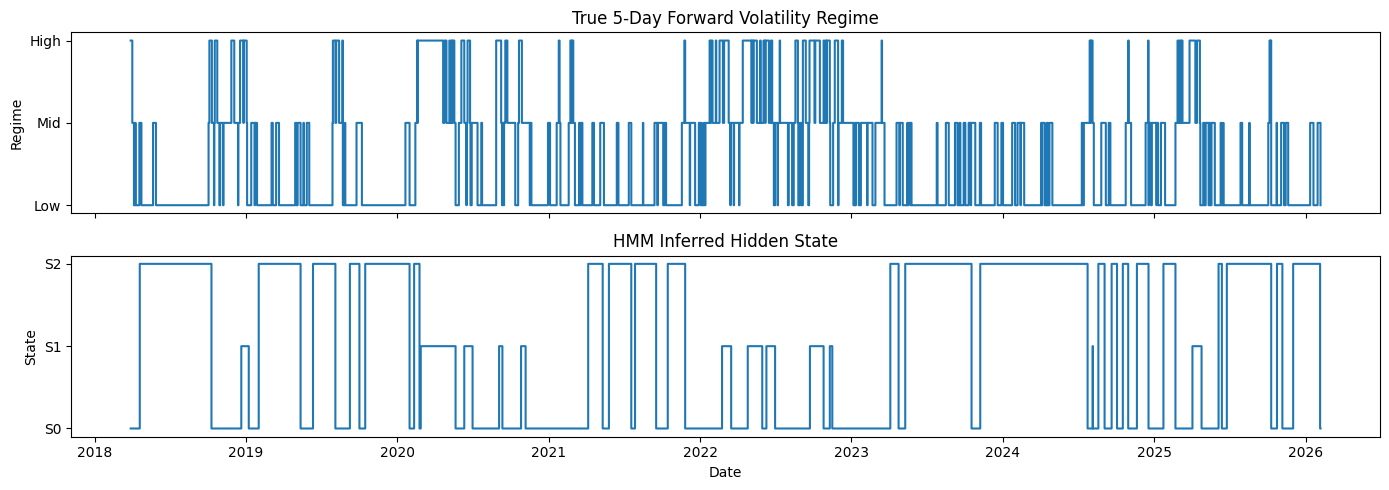

In [150]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work on HMM dataframe (already sorted)
plot_df = hmm_df.copy().sort_values("date")

# Map regimes to consistent ordering (0=Low,1=Mid,2=High)
plot_df["true_regime"] = plot_df["regime"].astype(int)
plot_df["hmm_state"] = plot_df["hmm_state"].astype(int)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# --------------------------
# Top: True Regime
# --------------------------
axes[0].plot(
    plot_df["date"],
    plot_df["true_regime"],
    drawstyle="steps-post"
)

axes[0].set_title("True 5-Day Forward Volatility Regime")
axes[0].set_ylabel("Regime")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Low", "Mid", "High"])

# --------------------------
# Bottom: HMM State
# --------------------------
axes[1].plot(
    plot_df["date"],
    plot_df["hmm_state"],
    drawstyle="steps-post"
)

axes[1].set_title("HMM Inferred Hidden State")
axes[1].set_ylabel("State")
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["S0", "S1", "S2"])

axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

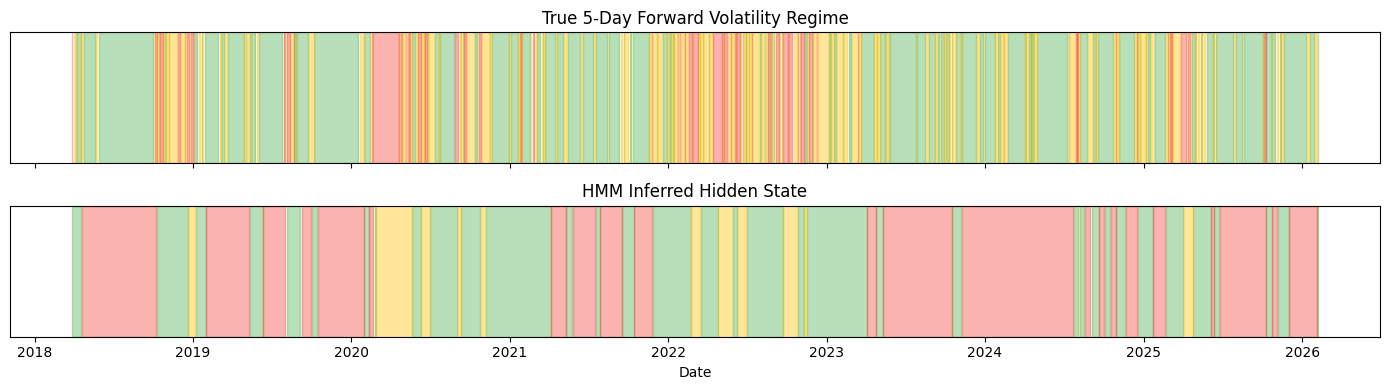

In [151]:
def regime_fill(ax, dates, values, title, labels):
    colors = ["#4CAF50", "#FFC107", "#F44336"]  # green/yellow/red
    
    for r in [0,1,2]:
        mask = values == r
        ax.fill_between(dates, 0, 1, where=mask, step="post", alpha=0.4, color=colors[r])
    
    ax.set_ylim(0,1)
    ax.set_yticks([])
    ax.set_title(title)

fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)

regime_fill(axes[0], plot_df["date"], plot_df["true_regime"], 
            "True 5-Day Forward Volatility Regime", ["Low","Mid","High"])

regime_fill(axes[1], plot_df["date"], plot_df["hmm_state"], 
            "HMM Inferred Hidden State", ["S0","S1","S2"])

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## K-Means Unsupervised Regime Discovery

We now apply K-Means clustering as a second unsupervised approach using the same SPY observation
features as HMM (`log_return`, `rv_10`, `vix_close`). Unlike HMM, K-Means does not model
temporal dynamics — it groups observations purely by feature similarity in standardized space.

In [80]:
from sklearn.cluster import KMeans

# Reuse X_train and X_all from HMM data preparation above
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_train)
km_labels_all = km.predict(X_all)

# Add K-Means labels to hmm_df, then rebuild tmp with both hmm_state and km_state
hmm_df["km_state"] = km_labels_all.astype(int)
tmp = hmm_df.dropna(subset=["regime"]).copy()

# Order clusters by mean rv_10 so cluster 0=low vol, 1=mid, 2=high vol
cluster_rv = tmp.groupby("km_state")["rv_10"].mean().sort_values()
km_order = {old: new for new, old in enumerate(cluster_rv.index)}
tmp["km_state"] = tmp["km_state"].map(km_order)
hmm_df["km_state"] = hmm_df["km_state"].map(km_order)

# Reorder cluster centers to match new ordering
km_centers = pd.DataFrame(
    km.cluster_centers_[list(cluster_rv.index)],
    columns=OBS_COLS,
    index=["Low Vol", "Mid Vol", "High Vol"],
)

# Color palette: green=low, orange=mid, red=high volatility
km_colors = {0: "green", 1: "orange", 2: "red"}

print("K-Means cluster centers (standardized):")
print(km_centers)

K-Means cluster centers (standardized):
          log_return     rv_10  vix_close
Low Vol     0.156527 -0.459584  -0.530904
Mid Vol    -0.267236  0.543399   0.711532
High Vol   -0.283424  5.226996   4.511406


### K-Means Regimes Over Time

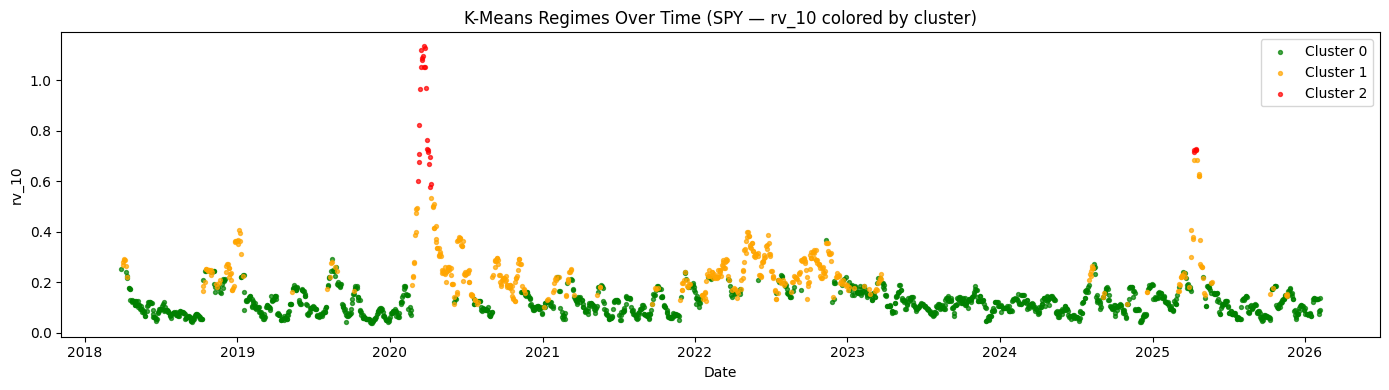

In [81]:
fig, ax = plt.subplots(figsize=(14, 4))
for state in range(N_STATES):
    mask = tmp["km_state"] == state
    ax.scatter(tmp.loc[mask, "date"], tmp.loc[mask, "rv_10"],
               c=km_colors[state], label=f"Cluster {state}", s=8, alpha=0.7)
ax.set_title("K-Means Regimes Over Time (SPY — rv_10 colored by cluster)")
ax.set_xlabel("Date")
ax.set_ylabel("rv_10")
ax.legend()
plt.tight_layout()
plt.show()

### K-Means Cluster Centers

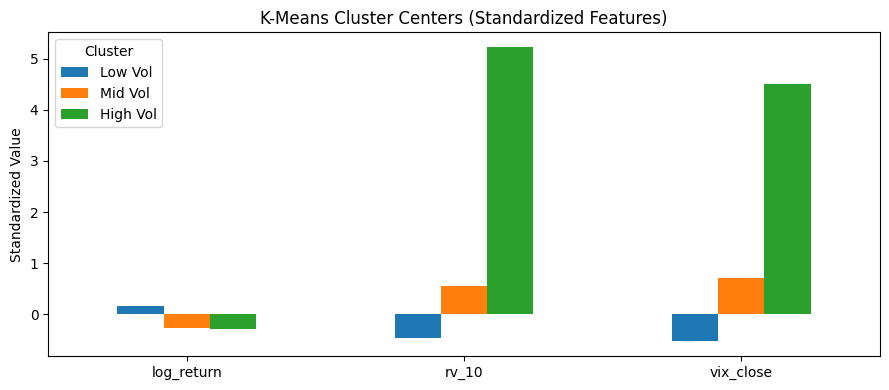

In [82]:
km_centers.T.plot(kind="bar", figsize=(9, 4))
plt.title("K-Means Cluster Centers (Standardized Features)")
plt.ylabel("Standardized Value")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### K-Means Regimes vs VIX Overlay

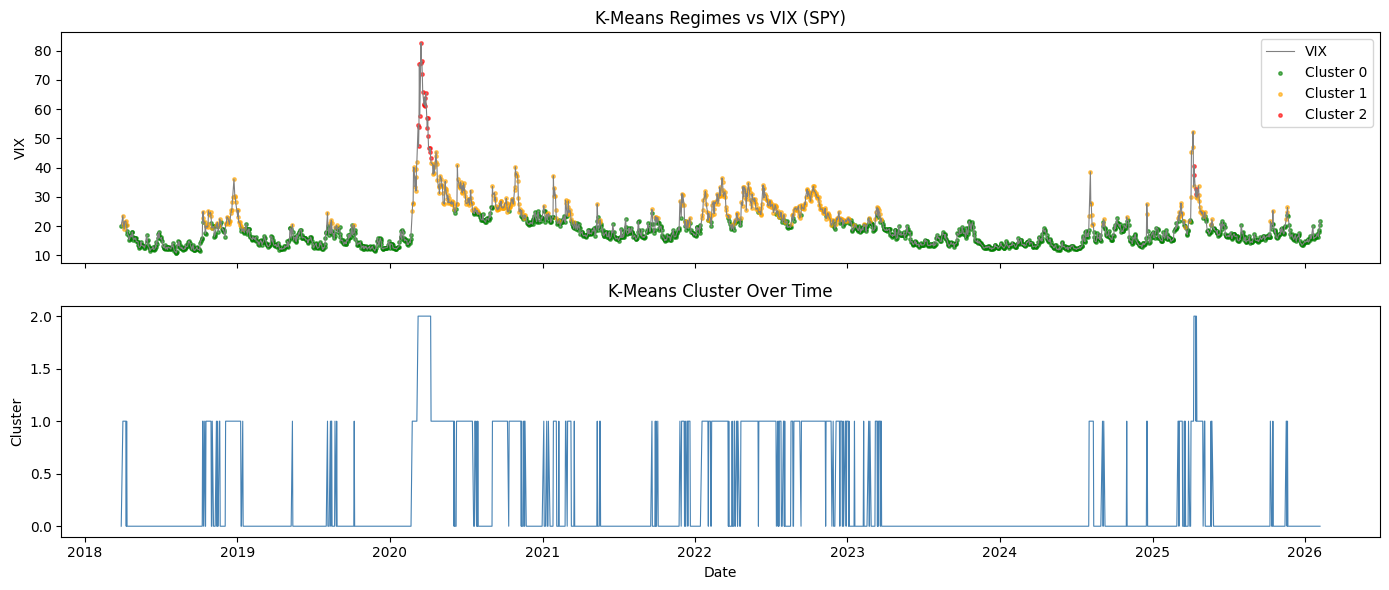

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(hmm_df["date"], hmm_df["vix_close"], color="gray", lw=0.8, label="VIX")
for state in range(N_STATES):
    mask = hmm_df["km_state"] == state
    axes[0].scatter(hmm_df.loc[mask, "date"], hmm_df.loc[mask, "vix_close"],
                    c=km_colors[state], s=6, alpha=0.6, label=f"Cluster {state}")
axes[0].set_title("K-Means Regimes vs VIX (SPY)")
axes[0].set_ylabel("VIX")
axes[0].legend()

axes[1].plot(hmm_df["date"], hmm_df["km_state"], color="steelblue", lw=0.8)
axes[1].set_title("K-Means Cluster Over Time")
axes[1].set_ylabel("Cluster")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## K-Means vs HMM Comparison

We now compare the two unsupervised approaches — K-Means and HMM — against each other and against
the supervised quantile-based regimes. ARI (Adjusted Rand Index) and NMI (Normalized Mutual
Information) measure clustering agreement, where 1.0 = perfect agreement and 0.0 = random.

In [84]:
ari_km_hmm  = adjusted_rand_score(tmp["hmm_state"], tmp["km_state"])
nmi_km_hmm  = normalized_mutual_info_score(tmp["hmm_state"], tmp["km_state"])
ari_hmm_sup = adjusted_rand_score(tmp["regime"].astype(int), tmp["hmm_state"])
nmi_hmm_sup = normalized_mutual_info_score(tmp["regime"].astype(int), tmp["hmm_state"])
ari_km_sup  = adjusted_rand_score(tmp["regime"].astype(int), tmp["km_state"])
nmi_km_sup  = normalized_mutual_info_score(tmp["regime"].astype(int), tmp["km_state"])

print(f"K-Means vs HMM          — ARI: {ari_km_hmm:.4f},  NMI: {nmi_km_hmm:.4f}")
print(f"HMM vs Quantile Regimes — ARI: {ari_hmm_sup:.4f}, NMI: {nmi_hmm_sup:.4f}")
print(f"K-Means vs Quantile     — ARI: {ari_km_sup:.4f},  NMI: {nmi_km_sup:.4f}")

summary = pd.DataFrame({
    "ARI vs Quantile Regimes": [ari_hmm_sup, ari_km_sup],
    "NMI vs Quantile Regimes": [nmi_hmm_sup, nmi_km_sup],
    "ARI vs Each Other": [ari_km_hmm, ari_km_hmm],
}, index=["HMM", "K-Means"])
display(summary)

K-Means vs HMM          — ARI: 0.2955,  NMI: 0.3845
HMM vs Quantile Regimes — ARI: 0.2105, NMI: 0.1893
K-Means vs Quantile     — ARI: 0.2619,  NMI: 0.1910


,ARI vs Quantile Regimes,NMI vs Quantile Regimes,ARI vs Each Other
HMM,0.210534,0.189277,0.295541
K-Means,0.261899,0.191006,0.295541


### K-Means vs HMM Cross-Tab

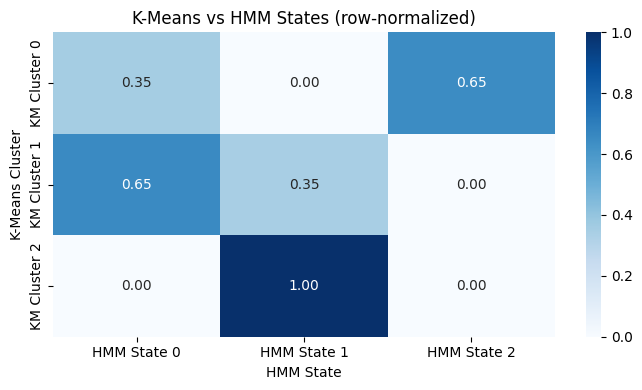

In [85]:
ct_km_hmm = pd.crosstab(tmp["km_state"], tmp["hmm_state"], normalize="index")
ct_km_hmm.index = [f"KM Cluster {i}" for i in ct_km_hmm.index]
ct_km_hmm.columns = [f"HMM State {c}" for c in ct_km_hmm.columns]

plt.figure(figsize=(7, 4))
sns.heatmap(ct_km_hmm, annot=True, fmt=".2f", cmap="Blues")
plt.title("K-Means vs HMM States (row-normalized)")
plt.xlabel("HMM State")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.show()

### Side-by-Side Regime Timeline: K-Means vs HMM

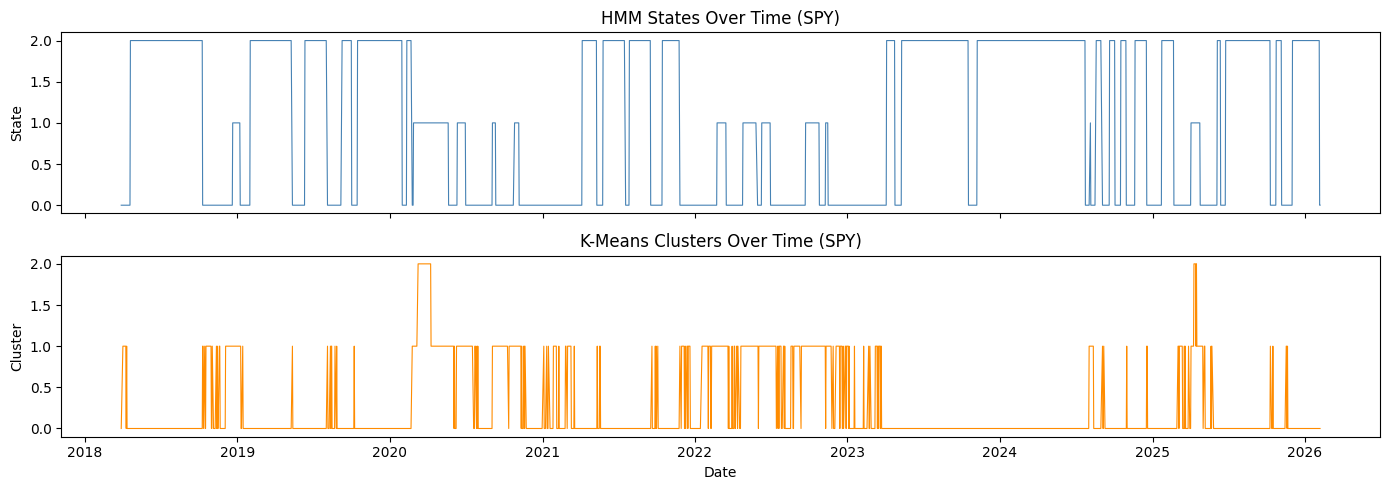

In [86]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(hmm_df["date"], hmm_df["hmm_state"], lw=0.8, color="steelblue")
axes[0].set_title("HMM States Over Time (SPY)")
axes[0].set_ylabel("State")

axes[1].plot(hmm_df["date"], hmm_df["km_state"], lw=0.8, color="darkorange")
axes[1].set_title("K-Means Clusters Over Time (SPY)")
axes[1].set_ylabel("Cluster")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### ARI / NMI Comparison: HMM vs K-Means

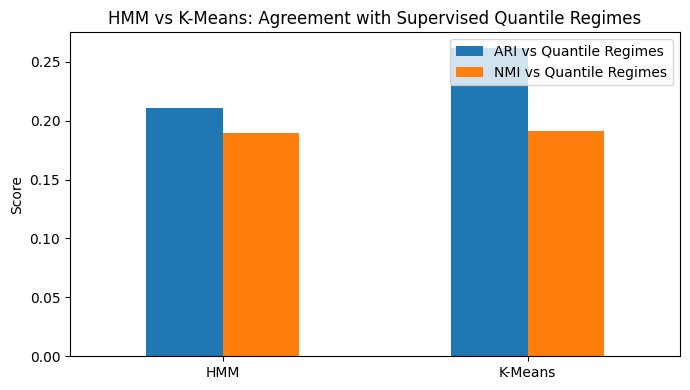

In [87]:
comparison = pd.DataFrame({
    "ARI vs Quantile Regimes": [ari_hmm_sup, ari_km_sup],
    "NMI vs Quantile Regimes": [nmi_hmm_sup, nmi_km_sup],
}, index=["HMM", "K-Means"])

comparison.plot(kind="bar", figsize=(7, 4), rot=0)
plt.title("HMM vs K-Means: Agreement with Supervised Quantile Regimes")
plt.ylabel("Score")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

END OF DOCUMENT

In [88]:
print("hello world")

hello world
